# LSTM vs Transformer — CS 110 Final Project Demo
This notebook trains a tiny LSTM and a tiny Transformer on the same task and compares their speed and accuracy side by side.

In [1]:
# CELL 1 — Install libraries (run once)
import subprocess
subprocess.run(['pip', 'install', 'torch', 'matplotlib', 'numpy'], capture_output=True)
print('Libraries ready!')

Libraries ready!


In [2]:
# CELL 2 — Imports
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

print('PyTorch version:', torch.__version__)
print('All imports successful!')

PyTorch version: 2.11.0
All imports successful!


In [3]:
# CELL 3 — The dataset
# We use a small chunk of text. The task: predict the next character.

text = """
To be or not to be that is the question whether tis nobler in the mind to suffer
the slings and arrows of outrageous fortune or to take arms against a sea of troubles
and by opposing end them to die to sleep no more and by a sleep to say we end
the heartache and the thousand natural shocks that flesh is heir to tis a consummation
devoutly to be wished to die to sleep to sleep perchance to dream ay there is the rub
for in that sleep of death what dreams may come when we have shuffled off this mortal coil
must give us pause there is the respect that makes calamity of so long life
for who would bear the whips and scorns of time the oppressors wrong the proud mans contumely
the pangs of despised love the laws delay the insolence of office and the spurns
that patient merit of the unworthy takes when he himself might his quietus make
with a bare bodkin who would fardels bear to grunt and sweat under a weary life
but that the dread of something after death the undiscovered country from whose bourn
no traveller returns puzzles the will and makes us rather bear those ills we have
than fly to others that we know not of thus conscience does make cowards of us all
""".strip().lower()

# Build character vocabulary
chars = sorted(set(text))
vocab_size = len(chars)
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}

# Encode text as integers
encoded = torch.tensor([char2idx[c] for c in text], dtype=torch.long)

print(f'Text length: {len(text)} characters')
print(f'Vocabulary size: {vocab_size} unique characters')
print(f'Characters: {chars}')

Text length: 1170 characters
Vocabulary size: 26 unique characters
Characters: ['\n', ' ', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'y', 'z']


In [4]:
# CELL 4 — Data preparation
SEQ_LEN = 40    # each input is 40 characters
BATCH_SIZE = 32

def make_batches(encoded, seq_len, batch_size):
    sequences, targets = [], []
    for i in range(0, len(encoded) - seq_len - 1, 2):
        sequences.append(encoded[i:i+seq_len])
        targets.append(encoded[i+1:i+seq_len+1])
    X = torch.stack(sequences)
    Y = torch.stack(targets)
    # shuffle
    idx = torch.randperm(len(X))
    X, Y = X[idx], Y[idx]
    # batch
    n_batches = len(X) // batch_size
    X = X[:n_batches*batch_size].view(n_batches, batch_size, seq_len)
    Y = Y[:n_batches*batch_size].view(n_batches, batch_size, seq_len)
    return X, Y

X, Y = make_batches(encoded, SEQ_LEN, BATCH_SIZE)
print(f'Input shape: {X.shape}  (batches x batch_size x seq_len)')
print(f'Ready to train!')

Input shape: torch.Size([17, 32, 40])  (batches x batch_size x seq_len)
Ready to train!


In [5]:
# CELL 5 — Define the LSTM model
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)          # (batch, seq, embed)
        out, _ = self.lstm(x)          # (batch, seq, hidden) — SEQUENTIAL
        return self.fc(out)            # (batch, seq, vocab)

lstm_model = LSTMModel(vocab_size)
lstm_params = sum(p.numel() for p in lstm_model.parameters())
print(f'LSTM model ready — {lstm_params:,} parameters')

LSTM model ready — 236,442 parameters


In [6]:
# CELL 6 — Define the Transformer model
class TransformerModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_heads=4, num_layers=2, seq_len=40):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_embedding = nn.Embedding(seq_len, embed_dim)  # position encoding
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=128, batch_first=True, dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, vocab_size)
        self.seq_len = seq_len

    def forward(self, x):
        positions = torch.arange(x.size(1)).unsqueeze(0)  # position indices
        x = self.embedding(x) + self.pos_embedding(positions)  # embed + position
        # causal mask: each position can only see previous positions
        mask = nn.Transformer.generate_square_subsequent_mask(x.size(1))
        out = self.transformer(x, mask=mask, is_causal=True)  # ALL POSITIONS PARALLEL
        return self.fc(out)

transformer_model = TransformerModel(vocab_size)
transformer_params = sum(p.numel() for p in transformer_model.parameters())
print(f'Transformer model ready — {transformer_params:,} parameters')

Transformer model ready — 72,858 parameters


In [7]:
# CELL 7 — Training function (used for both models)
def train_model(model, X, Y, epochs=15, lr=0.003):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    losses, accuracies, epoch_times = [], [], []
    
    for epoch in range(epochs):
        model.train()
        total_loss, total_correct, total_tokens = 0, 0, 0
        start = time.time()
        
        for batch_idx in range(len(X)):
            xb = X[batch_idx]   # (batch_size, seq_len)
            yb = Y[batch_idx]   # (batch_size, seq_len)
            
            optimizer.zero_grad()
            logits = model(xb)  # (batch_size, seq_len, vocab_size)
            
            # reshape for loss
            loss = criterion(logits.view(-1, vocab_size), yb.view(-1))
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            preds = logits.argmax(dim=-1)
            total_correct += (preds == yb).sum().item()
            total_tokens += yb.numel()
        
        epoch_time = time.time() - start
        avg_loss = total_loss / len(X)
        accuracy = total_correct / total_tokens * 100
        
        losses.append(avg_loss)
        accuracies.append(accuracy)
        epoch_times.append(epoch_time)
        
        print(f'  Epoch {epoch+1:2d}/{epochs} — Loss: {avg_loss:.4f}  Accuracy: {accuracy:.1f}%  Time: {epoch_time:.2f}s')
    
    return losses, accuracies, epoch_times

print('Training function ready!')

Training function ready!


In [8]:
# CELL 8 — Train the LSTM (takes ~1 min)
print('Training LSTM...')
print('=' * 55)
lstm_losses, lstm_acc, lstm_times = train_model(lstm_model, X, Y)
print(f'\nLSTM total training time: {sum(lstm_times):.1f}s')
print(f'Average time per epoch:   {np.mean(lstm_times):.2f}s')

Training LSTM...
  Epoch  1/15 — Loss: 2.9215  Accuracy: 17.1%  Time: 0.35s
  Epoch  2/15 — Loss: 2.4639  Accuracy: 31.6%  Time: 0.29s
  Epoch  3/15 — Loss: 2.0353  Accuracy: 41.7%  Time: 0.29s
  Epoch  4/15 — Loss: 1.6427  Accuracy: 51.7%  Time: 0.30s
  Epoch  5/15 — Loss: 1.2256  Accuracy: 65.5%  Time: 0.29s
  Epoch  6/15 — Loss: 0.8424  Accuracy: 78.8%  Time: 0.29s
  Epoch  7/15 — Loss: 0.5522  Accuracy: 88.0%  Time: 0.29s
  Epoch  8/15 — Loss: 0.3692  Accuracy: 92.4%  Time: 0.29s
  Epoch  9/15 — Loss: 0.2732  Accuracy: 94.0%  Time: 0.29s
  Epoch 10/15 — Loss: 0.2216  Accuracy: 94.6%  Time: 0.29s
  Epoch 11/15 — Loss: 0.1925  Accuracy: 95.0%  Time: 0.29s
  Epoch 12/15 — Loss: 0.1759  Accuracy: 95.3%  Time: 0.29s
  Epoch 13/15 — Loss: 0.1638  Accuracy: 95.5%  Time: 0.29s
  Epoch 14/15 — Loss: 0.1552  Accuracy: 95.5%  Time: 0.29s
  Epoch 15/15 — Loss: 0.1465  Accuracy: 95.6%  Time: 0.28s

LSTM total training time: 4.4s
Average time per epoch:   0.29s


In [9]:
# CELL 9 — Train the Transformer (takes ~1 min)
print('Training Transformer...')
print('=' * 55)
tf_losses, tf_acc, tf_times = train_model(transformer_model, X, Y)
print(f'\nTransformer total training time: {sum(tf_times):.1f}s')
print(f'Average time per epoch:          {np.mean(tf_times):.2f}s')

Training Transformer...
  Epoch  1/15 — Loss: 2.7288  Accuracy: 24.2%  Time: 0.20s
  Epoch  2/15 — Loss: 2.3266  Accuracy: 32.8%  Time: 0.20s
  Epoch  3/15 — Loss: 2.1910  Accuracy: 34.4%  Time: 0.20s
  Epoch  4/15 — Loss: 2.1039  Accuracy: 35.5%  Time: 0.20s
  Epoch  5/15 — Loss: 2.0196  Accuracy: 37.2%  Time: 0.20s
  Epoch  6/15 — Loss: 1.9340  Accuracy: 39.5%  Time: 0.20s
  Epoch  7/15 — Loss: 1.8339  Accuracy: 41.7%  Time: 0.20s
  Epoch  8/15 — Loss: 1.7372  Accuracy: 44.3%  Time: 0.21s
  Epoch  9/15 — Loss: 1.6293  Accuracy: 47.5%  Time: 0.20s
  Epoch 10/15 — Loss: 1.5136  Accuracy: 51.2%  Time: 0.20s
  Epoch 11/15 — Loss: 1.4034  Accuracy: 54.5%  Time: 0.20s
  Epoch 12/15 — Loss: 1.2888  Accuracy: 58.3%  Time: 0.20s
  Epoch 13/15 — Loss: 1.1836  Accuracy: 61.8%  Time: 0.20s
  Epoch 14/15 — Loss: 1.0772  Accuracy: 64.5%  Time: 0.19s
  Epoch 15/15 — Loss: 0.9808  Accuracy: 68.2%  Time: 0.20s

Transformer total training time: 3.0s
Average time per epoch:          0.20s


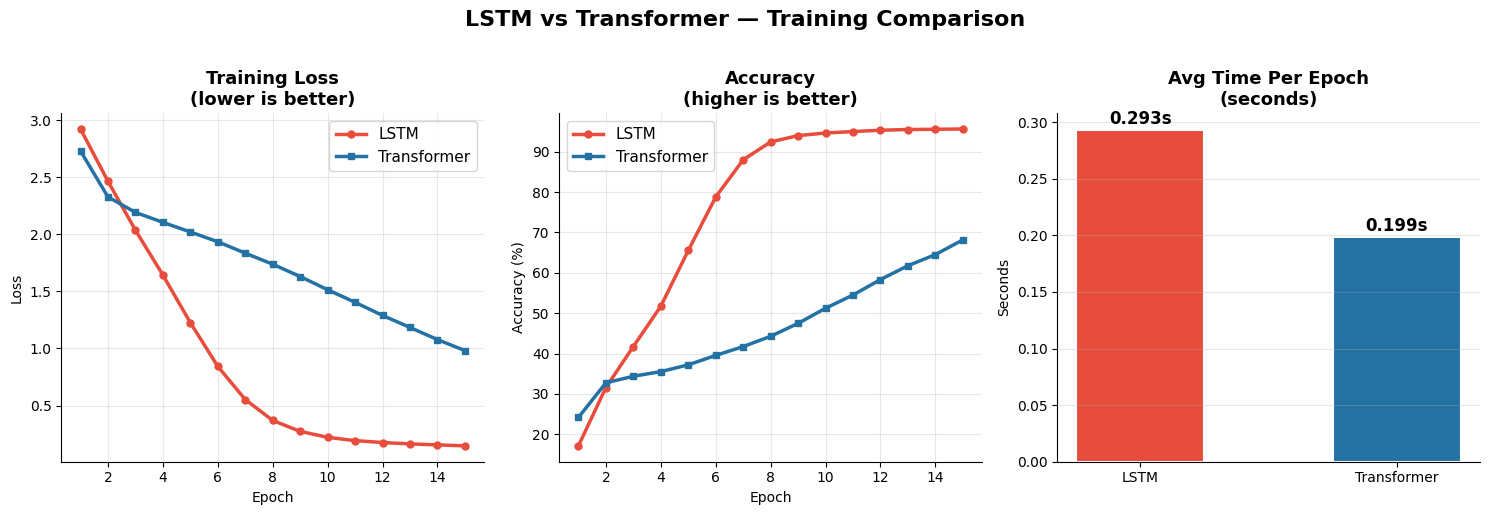

Chart saved as lstm_vs_transformer.png


In [10]:
# CELL 10 — Plot everything side by side
epochs = range(1, 16)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('LSTM vs Transformer — Training Comparison', fontsize=16, fontweight='bold', y=1.02)

LSTM_COLOR = '#E74C3C'        # red
TRANSFORMER_COLOR = '#2471A3' # blue

# --- Plot 1: Loss ---
ax = axes[0]
ax.plot(epochs, lstm_losses, color=LSTM_COLOR, linewidth=2.5, marker='o', markersize=5, label='LSTM')
ax.plot(epochs, tf_losses, color=TRANSFORMER_COLOR, linewidth=2.5, marker='s', markersize=5, label='Transformer')
ax.set_title('Training Loss\n(lower is better)', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Plot 2: Accuracy ---
ax = axes[1]
ax.plot(epochs, lstm_acc, color=LSTM_COLOR, linewidth=2.5, marker='o', markersize=5, label='LSTM')
ax.plot(epochs, tf_acc, color=TRANSFORMER_COLOR, linewidth=2.5, marker='s', markersize=5, label='Transformer')
ax.set_title('Accuracy\n(higher is better)', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Plot 3: Time per epoch ---
ax = axes[2]
ax.bar(['LSTM', 'Transformer'],
       [np.mean(lstm_times), np.mean(tf_times)],
       color=[LSTM_COLOR, TRANSFORMER_COLOR],
       width=0.5, edgecolor='white', linewidth=1.5)
ax.set_title('Avg Time Per Epoch\n(seconds)', fontsize=13, fontweight='bold')
ax.set_ylabel('Seconds')
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, v in enumerate([np.mean(lstm_times), np.mean(tf_times)]):
    ax.text(i, v + 0.005, f'{v:.3f}s', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('lstm_vs_transformer.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as lstm_vs_transformer.png')

In [11]:
# CELL 11 — Summary printout
print('=' * 55)
print('           FINAL RESULTS SUMMARY')
print('=' * 55)
print(f'  LSTM      — Final Accuracy: {lstm_acc[-1]:.1f}%   Avg Epoch: {np.mean(lstm_times):.3f}s')
print(f'  Transformer — Final Accuracy: {tf_acc[-1]:.1f}%   Avg Epoch: {np.mean(tf_times):.3f}s')
print('=' * 55)
faster = 'Transformer' if np.mean(tf_times) < np.mean(lstm_times) else 'LSTM'
ratio = max(np.mean(lstm_times), np.mean(tf_times)) / min(np.mean(lstm_times), np.mean(tf_times))
print(f'  {faster} was {ratio:.1f}x faster per epoch on this hardware')
print()
print('  Key insight: On a small CPU dataset the difference is')
print('  modest. On real GPU clusters with long sequences,')
print('  the Transformer gap grows dramatically because GPU')
print('  cores stay fully utilized — LSTM cores mostly idle.')
print('=' * 55)

           FINAL RESULTS SUMMARY
  LSTM      — Final Accuracy: 95.6%   Avg Epoch: 0.293s
  Transformer — Final Accuracy: 68.2%   Avg Epoch: 0.199s
  Transformer was 1.5x faster per epoch on this hardware

  Key insight: On a small CPU dataset the difference is
  modest. On real GPU clusters with long sequences,
  the Transformer gap grows dramatically because GPU
  cores stay fully utilized — LSTM cores mostly idle.
